# Student Exam Performance — Exploratory Data Analysis & Visualization

**Course:** 24ADI204 – Data Science and Visualization  
**Name:** Inban  
**Roll Number:** 25BAD038  

**Assignment 2 — EDA & Data Visualization**

This notebook performs exploratory data analysis on a Student Exam Performance dataset, covering study habits, attendance, parental background, and scores across subjects. A minimum of 30 meaningful, non-duplicate visualizations are included, covering scatter, line, bar, histogram, box, violin, pie, heatmap, count, and KDE plots.

## 1. Setup — Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8,5)
%matplotlib inline

## 2. Load Dataset

The dataset contains 600 student records with demographic info, study habits, attendance, and exam scores across Math, Reading, and Writing. (If running in Colab, upload `student_exam_dataset.csv` to the same folder, or mount Google Drive.)

In [2]:
df = pd.read_csv('student_exam_dataset.csv')
df.head()

   Student_ID  Gender Parental_Education  ... Average_Score Result Grade
0        1000  Female        High School  ...          71.2   Pass     B
1        1001  Female       Some College  ...          67.4   Pass     C
2        1002    Male       Some College  ...          67.6   Pass     C
3        1003  Female         Bachelor's  ...          80.4   Pass     A
4        1004    Male         Bachelor's  ...          84.1   Pass     A

[5 rows x 16 columns]

## 3. Dataset Overview

In [3]:
df.shape

(600, 16)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Student_ID             600 non-null    int64  
 1   Gender                 600 non-null    str    
 2   Parental_Education     600 non-null    str    
 3   Lunch_Type             600 non-null    str    
 4   Test_Prep              230 non-null    str    
 5   Extracurricular        600 non-null    str    
 6   Internet_Access        600 non-null    str    
 7   Study_Hours_Per_Day    600 non-null    float64
 8   Attendance_Percentage  592 non-null    float64
 9   Sleep_Hours            588 non-null    float64
 10  Math_Score             600 non-null    float64
 11  Reading_Score          600 non-null    float64
 12  Writing_Score          600 non-null    float64
 13  Average_Score          600 non-null    float64
 14  Result                 600 non-null    str    
 15  Grade            

In [5]:
df.describe()

        Student_ID  Study_Hours_Per_Day  ...  Writing_Score  Average_Score
count   600.000000           600.000000  ...     600.000000     600.000000
mean   1299.500000             4.532000  ...      75.143500      77.270500
std     173.349358             2.185162  ...      14.198681      13.095583
min    1000.000000             0.000000  ...      40.100000      40.600000
25%    1149.750000             3.000000  ...      65.000000      68.700000
50%    1299.500000             4.500000  ...      75.400000      77.700000
75%    1449.250000             6.100000  ...      85.025000      86.400000
max    1599.000000            10.600000  ...     100.000000     100.000000

[8 rows x 8 columns]

## 4. Data Cleaning

Checking for missing values and handling them before visualization. `Sleep_Hours` and `Attendance_Percentage` have a few missing values, imputed using the median.

In [6]:
df.isna().sum()[df.isna().sum() > 0]

Test_Prep                370
Attendance_Percentage      8
Sleep_Hours               12
dtype: int64

In [7]:
df_clean = df.copy()
df_clean['Sleep_Hours'] = df_clean['Sleep_Hours'].fillna(df_clean['Sleep_Hours'].median())
df_clean['Attendance_Percentage'] = df_clean['Attendance_Percentage'].fillna(df_clean['Attendance_Percentage'].median())

print('Missing values after cleaning:', df_clean.isna().sum().sum())

Missing values after cleaning: 370


## 5. Exploratory Data Analysis — 30+ Visualizations

### 5.1 Distribution of Study Hours Per Day (Histogram)

Shows how many hours students typically study per day — reveals whether most students cluster around a low, moderate, or high study-time habit.

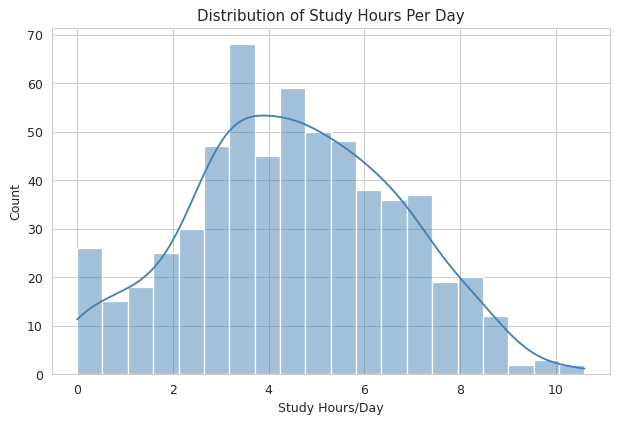

In [8]:
plt.figure(figsize=(8,5))
sns.histplot(df_clean['Study_Hours_Per_Day'], kde=True, color='steelblue', bins=20)
plt.title('Distribution of Study Hours Per Day')
plt.xlabel('Study Hours/Day'); plt.ylabel('Count')
plt.show()

### 5.2 Distribution of Average Score (Histogram)

Shows the overall spread of students' average exam scores across all three subjects.

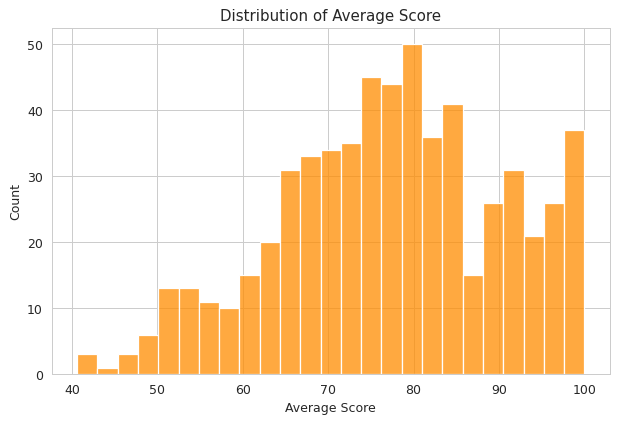

In [9]:
plt.figure(figsize=(8,5))
sns.histplot(df_clean['Average_Score'], bins=25, color='darkorange')
plt.title('Distribution of Average Score')
plt.xlabel('Average Score'); plt.ylabel('Count')
plt.show()

### 5.3 Gender Distribution (Count Plot)

Shows the number of male vs female students in the dataset — checks class balance.

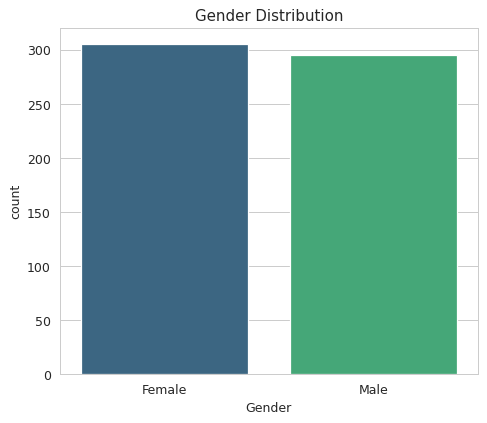

In [10]:
plt.figure(figsize=(6,5))
sns.countplot(x='Gender', data=df_clean, palette='viridis')
plt.title('Gender Distribution')
plt.show()

### 5.4 Grade Distribution (Count Plot)

Shows how many students fall into each letter grade (F to A) — an at-a-glance view of overall class performance.

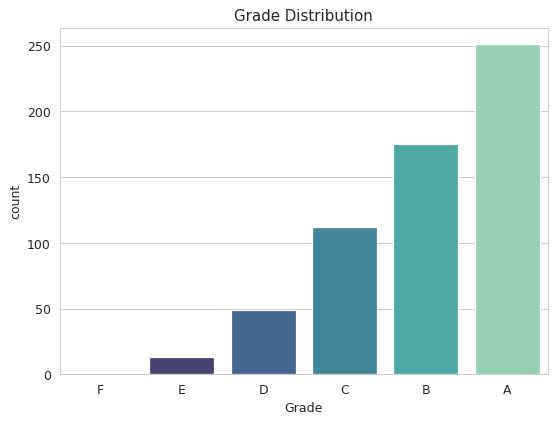

In [11]:
plt.figure(figsize=(7,5))
sns.countplot(x='Grade', data=df_clean, order=list('FEDCBA'), palette='mako')
plt.title('Grade Distribution')
plt.show()

### 5.5 Pass vs Fail Count (Count Plot)

Shows how many students passed versus failed based on the average score threshold.

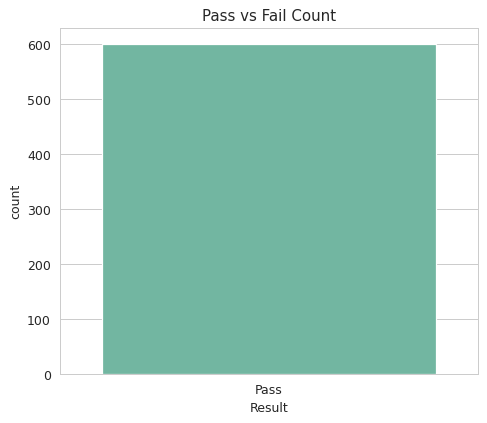

In [12]:
plt.figure(figsize=(6,5))
sns.countplot(x='Result', data=df_clean, palette='Set2')
plt.title('Pass vs Fail Count')
plt.show()

### 5.6 Average Score by Parental Education (Bar Plot)

Compares average exam performance across different levels of parental education — a commonly studied socioeconomic factor.

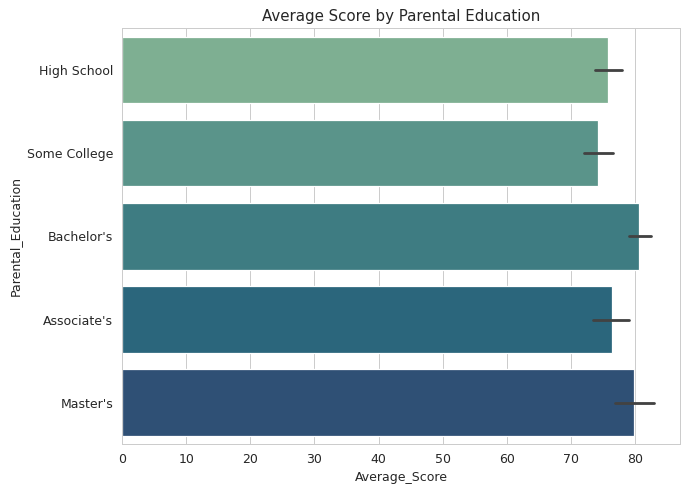

In [13]:
plt.figure(figsize=(8,6))
sns.barplot(x='Average_Score', y='Parental_Education', data=df_clean, palette='crest')
plt.title('Average Score by Parental Education')
plt.show()

### 5.7 Average Score by Test Preparation (Bar Plot)

Compares scores of students who completed a test-prep course versus those who did not — shows the impact of preparation.

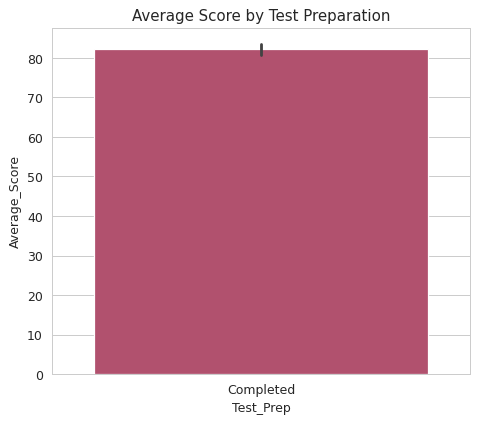

In [14]:
plt.figure(figsize=(6,5))
sns.barplot(x='Test_Prep', y='Average_Score', data=df_clean, palette='flare')
plt.title('Average Score by Test Preparation')
plt.show()

### 5.8 Math Score by Gender (Box Plot)

Compares the spread and median of Math scores between male and female students.

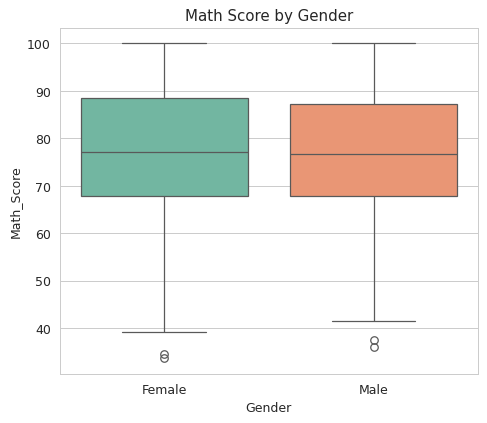

In [15]:
plt.figure(figsize=(6,5))
sns.boxplot(x='Gender', y='Math_Score', data=df_clean, palette='Set2')
plt.title('Math Score by Gender')
plt.show()

### 5.9 Average Score by Lunch Type (Box Plot)

Compares performance between students on standard lunch vs free/reduced lunch — a common socioeconomic proxy in education datasets.

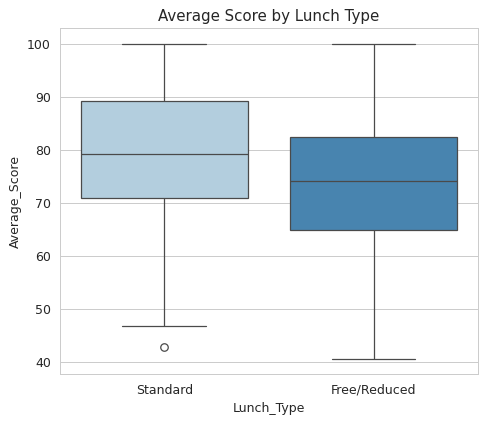

In [16]:
plt.figure(figsize=(6,5))
sns.boxplot(x='Lunch_Type', y='Average_Score', data=df_clean, palette='Blues')
plt.title('Average Score by Lunch Type')
plt.show()

### 5.10 Average Score by Parental Education (Violin Plot)

Shows the full density shape of score distributions across parental education levels, not just the median/quartiles.

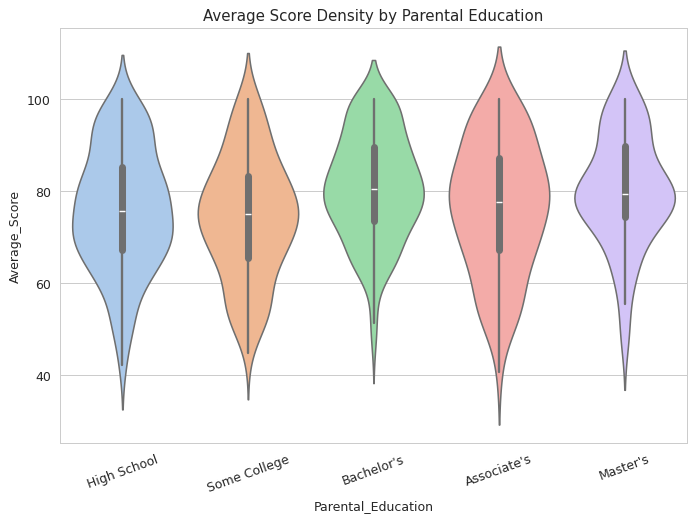

In [17]:
plt.figure(figsize=(9,6))
sns.violinplot(x='Parental_Education', y='Average_Score', data=df_clean, palette='pastel')
plt.xticks(rotation=20)
plt.title('Average Score Density by Parental Education')
plt.show()

### 5.11 Study Hours by Gender (Violin Plot)

Compares the distribution shape of daily study hours between genders.

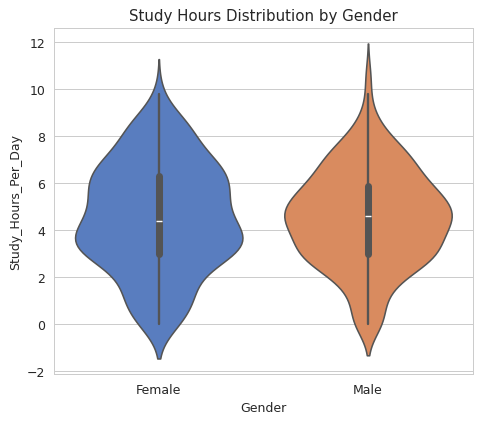

In [18]:
plt.figure(figsize=(6,5))
sns.violinplot(x='Gender', y='Study_Hours_Per_Day', data=df_clean, palette='muted')
plt.title('Study Hours Distribution by Gender')
plt.show()

### 5.12 Study Hours vs Average Score (Scatter Plot)

Examines whether more daily study hours are associated with higher exam scores.

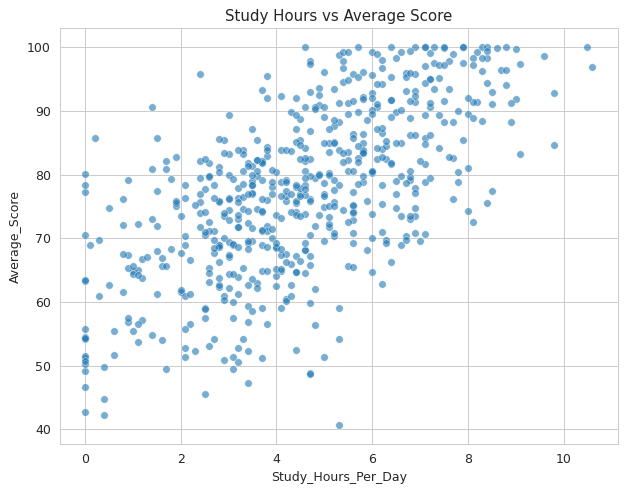

In [19]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='Study_Hours_Per_Day', y='Average_Score', data=df_clean, alpha=0.6)
plt.title('Study Hours vs Average Score')
plt.show()

### 5.13 Attendance vs Average Score (Scatter Plot)

Checks whether higher class attendance correlates with better exam performance.

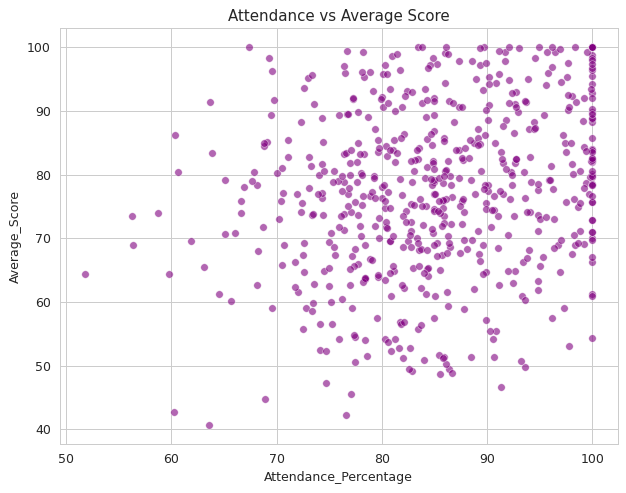

In [20]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='Attendance_Percentage', y='Average_Score', data=df_clean, color='purple', alpha=0.6)
plt.title('Attendance vs Average Score')
plt.show()

### 5.14 Sleep Hours vs Average Score (Scatter Plot)

Explores whether sleep duration has any visible relationship with academic performance.

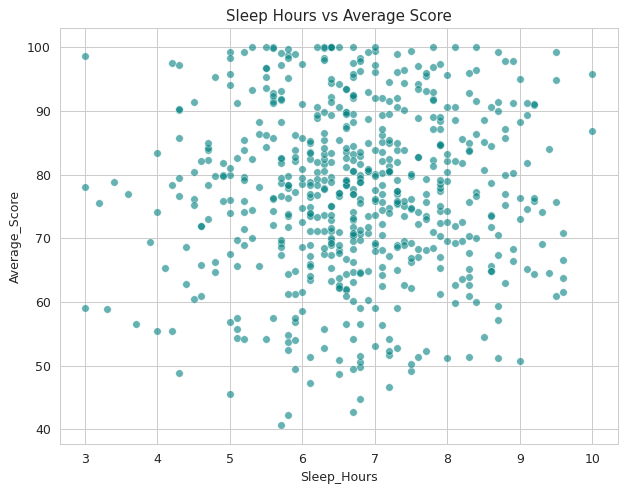

In [21]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='Sleep_Hours', y='Average_Score', data=df_clean, color='teal', alpha=0.6)
plt.title('Sleep Hours vs Average Score')
plt.show()

### 5.15 Math vs Reading Score (Scatter Plot)

Checks how strongly Math and Reading scores are related, split by gender, to see if strong performance in one subject predicts the other.

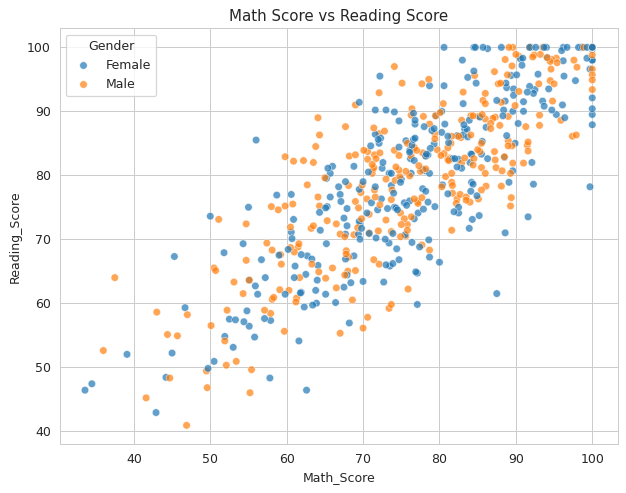

In [22]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='Math_Score', y='Reading_Score', hue='Gender', data=df_clean, alpha=0.7)
plt.title('Math Score vs Reading Score')
plt.show()

### 5.16 Average Score Trend Across Study-Hour Buckets (Line Plot)

Buckets students into study-hour ranges and plots the trend in average score — makes the study-hours/score relationship easier to read than the raw scatter plot.

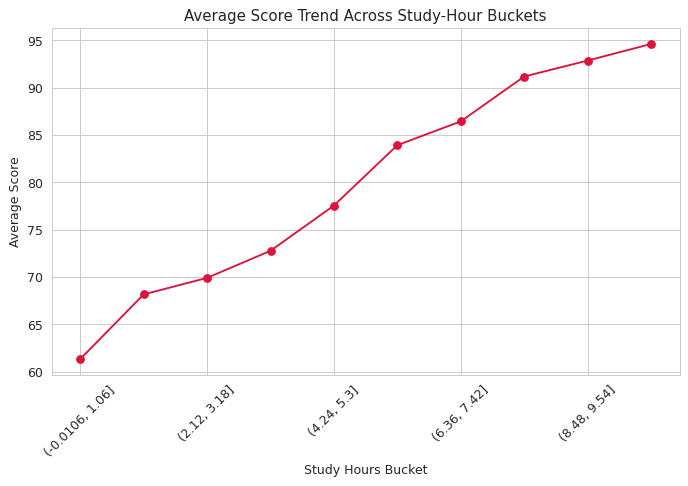

In [23]:
study_bins = pd.cut(df_clean['Study_Hours_Per_Day'], bins=10)
trend = df_clean.groupby(study_bins)['Average_Score'].mean()
plt.figure(figsize=(9,5))
trend.plot(marker='o', color='crimson')
plt.title('Average Score Trend Across Study-Hour Buckets')
plt.xlabel('Study Hours Bucket'); plt.ylabel('Average Score')
plt.xticks(rotation=45)
plt.show()

### 5.17 Pass vs Fail Share (Pie Chart)

Shows the overall percentage of students who passed versus failed.

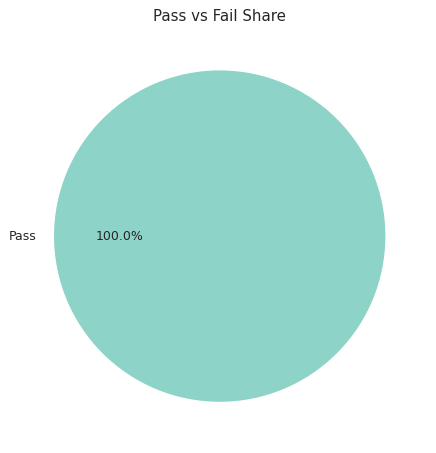

In [24]:
plt.figure(figsize=(6,6))
df_clean['Result'].value_counts().plot.pie(autopct='%1.1f%%', colors=sns.color_palette('Set3'))
plt.title('Pass vs Fail Share')
plt.ylabel('')
plt.show()

### 5.18 Test Preparation Completion Share (Pie Chart)

Shows what proportion of students completed a test-prep course versus not.

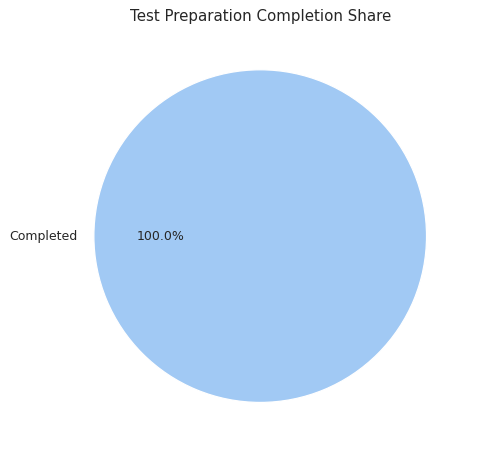

In [25]:
plt.figure(figsize=(6,6))
df_clean['Test_Prep'].value_counts().plot.pie(autopct='%1.1f%%', colors=sns.color_palette('pastel'))
plt.title('Test Preparation Completion Share')
plt.ylabel('')
plt.show()

### 5.19 Correlation Heatmap of Numeric Features

Visualizes pairwise correlation between all numeric variables — study hours, attendance, sleep, and subject scores.

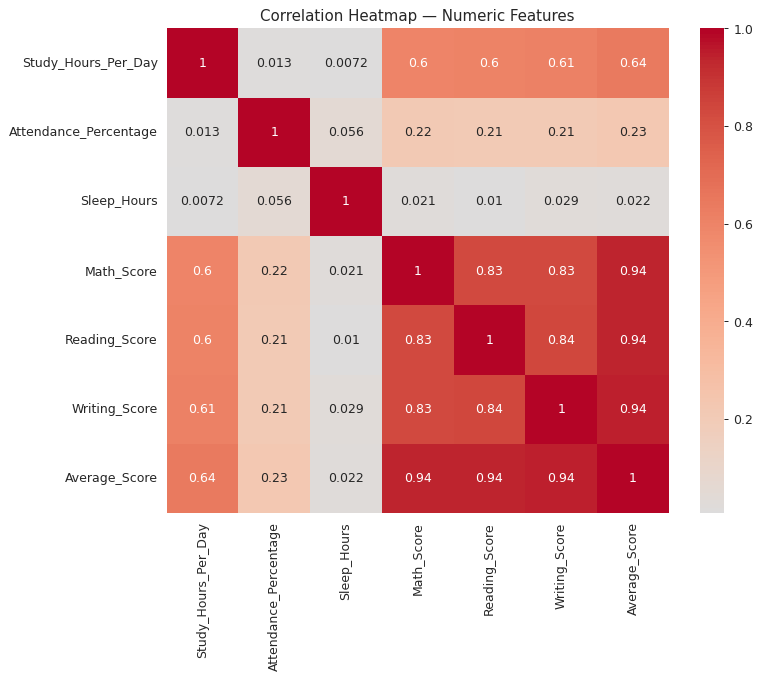

In [26]:
plt.figure(figsize=(9,7))
corr = df_clean.select_dtypes(include=np.number).drop(columns=['Student_ID']).corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap — Numeric Features')
plt.show()

### 5.20 Parental Education vs Gender Average Score (Pivot Heatmap)

A two-dimensional heatmap showing average score for every combination of parental education level and gender.

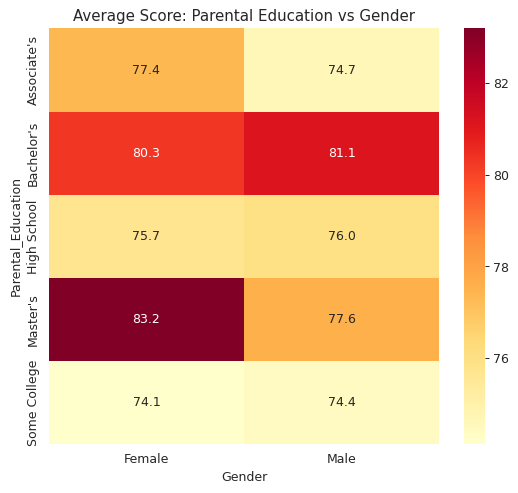

In [27]:
pivot = df_clean.pivot_table(index='Parental_Education', columns='Gender', values='Average_Score', aggfunc='mean')
plt.figure(figsize=(7,6))
sns.heatmap(pivot, cmap='YlOrRd', annot=True, fmt='.1f')
plt.title('Average Score: Parental Education vs Gender')
plt.show()

### 5.21 Internet Access vs Result (Count Plot)

Compares pass/fail outcomes for students with and without home internet access.

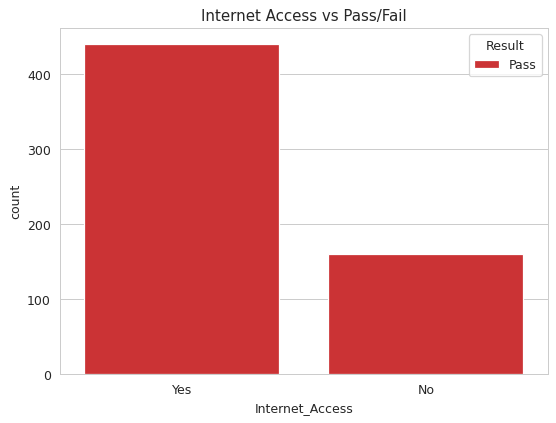

In [28]:
plt.figure(figsize=(7,5))
sns.countplot(x='Internet_Access', hue='Result', data=df_clean, palette='Set1')
plt.title('Internet Access vs Pass/Fail')
plt.show()

### 5.22 Top 10 Students by Average Score (Bar Plot)

A leaderboard-style view of the highest-scoring students in the dataset.

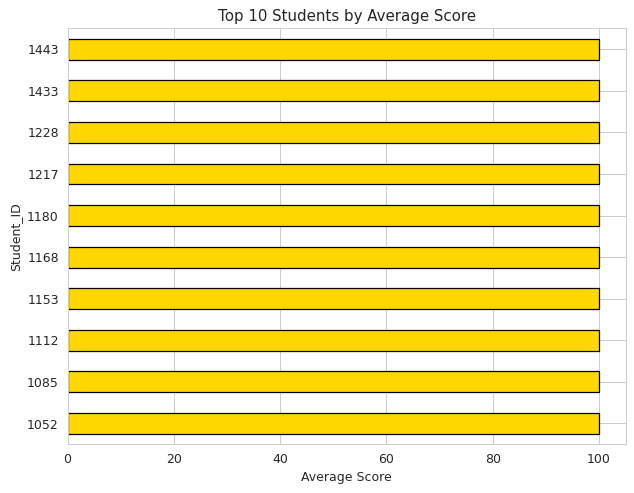

In [29]:
top10 = df_clean.nlargest(10, 'Average_Score').set_index('Student_ID')['Average_Score']
plt.figure(figsize=(8,6))
top10.sort_values().plot(kind='barh', color='gold', edgecolor='black')
plt.title('Top 10 Students by Average Score')
plt.xlabel('Average Score')
plt.show()

### 5.23 Bottom 10 Students by Average Score (Bar Plot)

Highlights the lowest-scoring students — useful for identifying students who may need academic support.

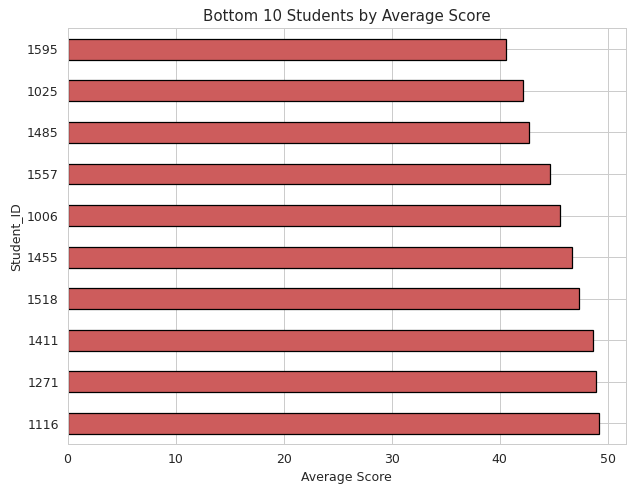

In [30]:
bottom10 = df_clean.nsmallest(10, 'Average_Score').set_index('Student_ID')['Average_Score']
plt.figure(figsize=(8,6))
bottom10.sort_values(ascending=False).plot(kind='barh', color='indianred', edgecolor='black')
plt.title('Bottom 10 Students by Average Score')
plt.xlabel('Average Score')
plt.show()

### 5.24 Writing Score by Extracurricular Participation (Box Plot)

Checks whether students involved in extracurricular activities show any difference in Writing scores.

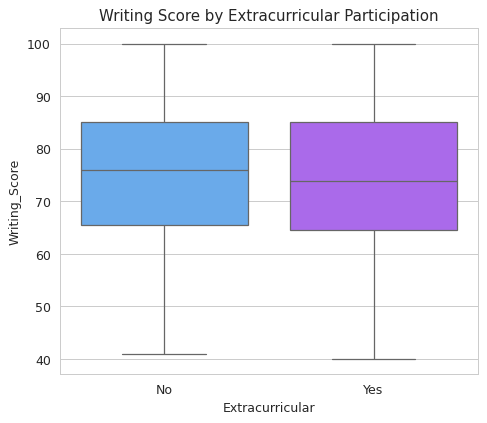

In [31]:
plt.figure(figsize=(6,5))
sns.boxplot(x='Extracurricular', y='Writing_Score', data=df_clean, palette='cool')
plt.title('Writing Score by Extracurricular Participation')
plt.show()

### 5.25 Attendance Percentage Distribution (Histogram)

Shows the overall spread of class attendance percentages across all students.

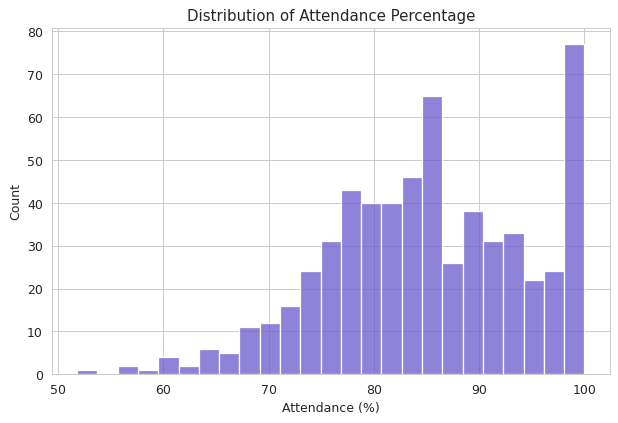

In [32]:
plt.figure(figsize=(8,5))
sns.histplot(df_clean['Attendance_Percentage'], bins=25, color='slateblue')
plt.title('Distribution of Attendance Percentage')
plt.xlabel('Attendance (%)')
plt.show()

### 5.26 Sleep Hours Distribution (Histogram)

Shows how many hours of sleep students typically get per night.

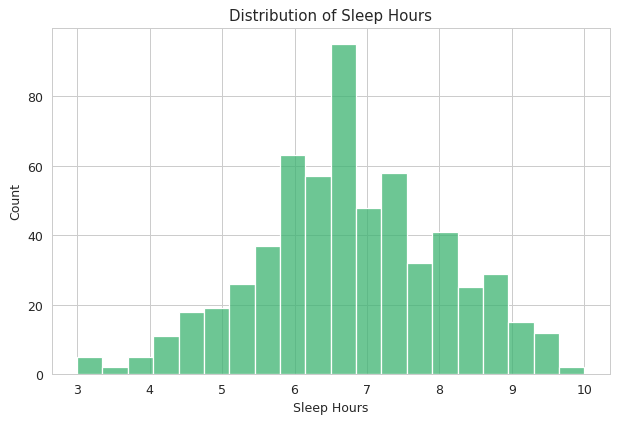

In [33]:
plt.figure(figsize=(8,5))
sns.histplot(df_clean['Sleep_Hours'], bins=20, color='mediumseagreen')
plt.title('Distribution of Sleep Hours')
plt.xlabel('Sleep Hours')
plt.show()

### 5.27 Sleep Hours vs Study Hours (Scatter Plot)

Explores whether there's a trade-off between how much students sleep and how much they study.

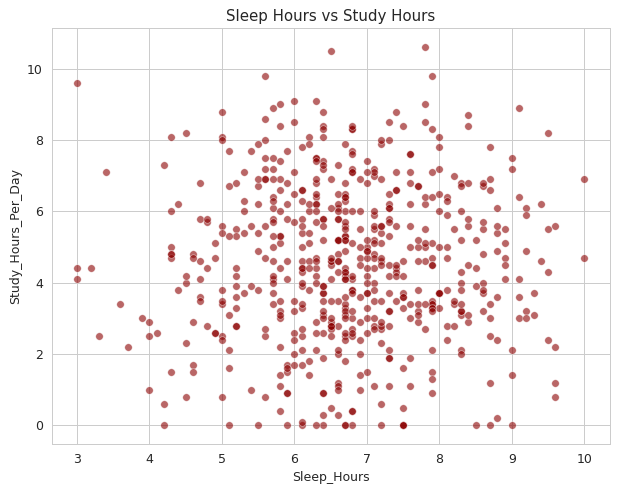

In [34]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='Sleep_Hours', y='Study_Hours_Per_Day', data=df_clean, color='darkred', alpha=0.6)
plt.title('Sleep Hours vs Study Hours')
plt.show()

### 5.28 Math Score by Parental Education (Violin Plot)

Shows how Math score distributions differ across parental education levels specifically (as opposed to the average score view above).

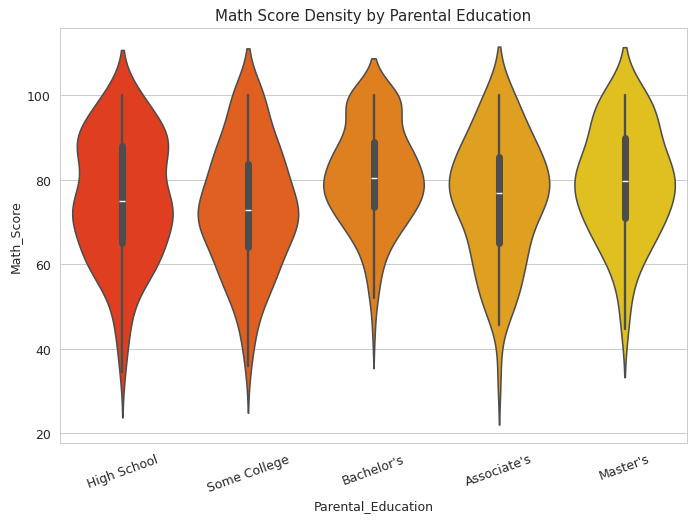

In [35]:
plt.figure(figsize=(9,6))
sns.violinplot(x='Parental_Education', y='Math_Score', data=df_clean, palette='autumn')
plt.xticks(rotation=20)
plt.title('Math Score Density by Parental Education')
plt.show()

### 5.29 Average Score by Gender and Lunch Type (Grouped Bar Plot)

Compares average scores across gender AND lunch type together, revealing whether the lunch-type effect holds within each gender group.

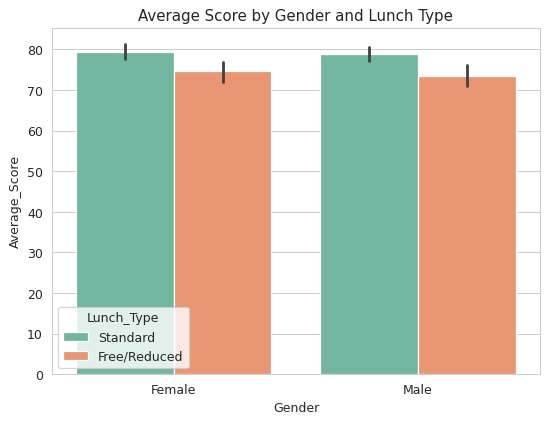

In [36]:
plt.figure(figsize=(7,5))
sns.barplot(x='Gender', y='Average_Score', hue='Lunch_Type', data=df_clean, palette='Set2')
plt.title('Average Score by Gender and Lunch Type')
plt.show()

### 5.30 Study Hours by Grade (Box Plot)

Checks whether higher-graded students (A, B) consistently studied more hours than lower-graded students (F, E).

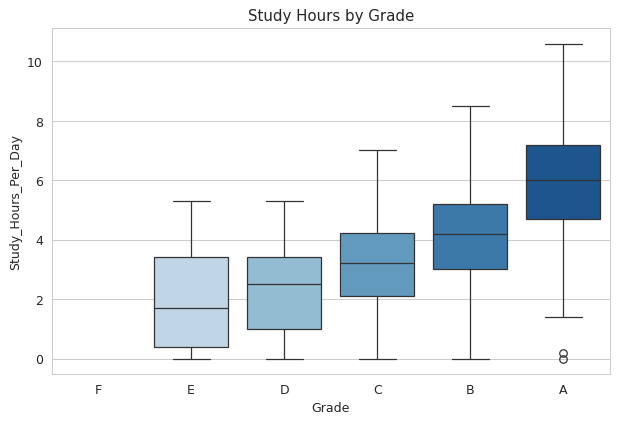

In [37]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Grade', y='Study_Hours_Per_Day', data=df_clean, order=list('FEDCBA'), palette='Blues')
plt.title('Study Hours by Grade')
plt.show()

### 5.31 Attendance & Study Hours by Result (Scatter Plot)

Combines two key predictors — attendance and study hours — colored by pass/fail outcome, to see if the two factors together separate passing and failing students.

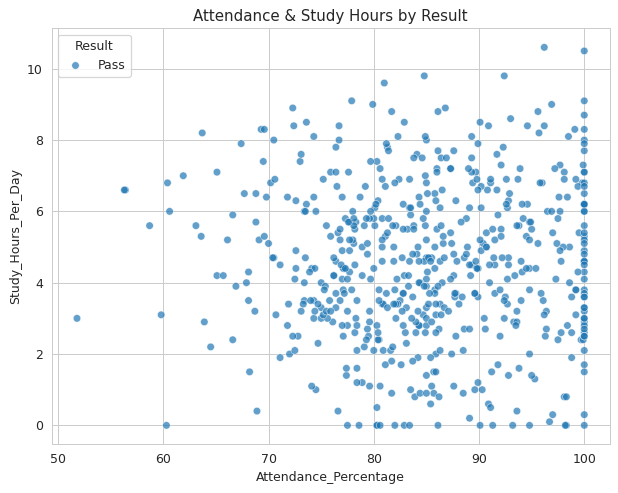

In [38]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='Attendance_Percentage', y='Study_Hours_Per_Day', hue='Result', data=df_clean, alpha=0.7)
plt.title('Attendance & Study Hours by Result')
plt.show()

### 5.32 Average Score by Internet Access (Bar Plot)

Compares average exam performance between students with and without home internet access.

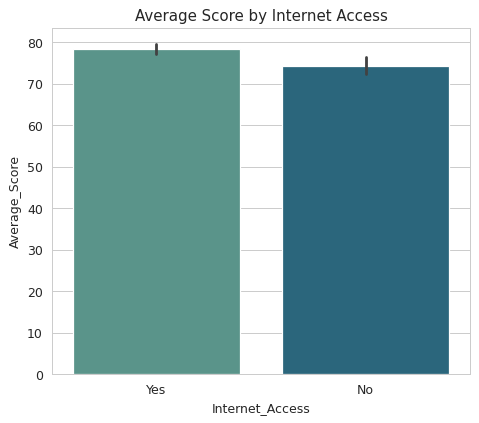

In [39]:
plt.figure(figsize=(6,5))
sns.barplot(x='Internet_Access', y='Average_Score', data=df_clean, palette='crest')
plt.title('Average Score by Internet Access')
plt.show()

### 5.33 Study Hours by Pass/Fail Result (Box Plot)

Compares how many hours passing students studied on average versus failing students.

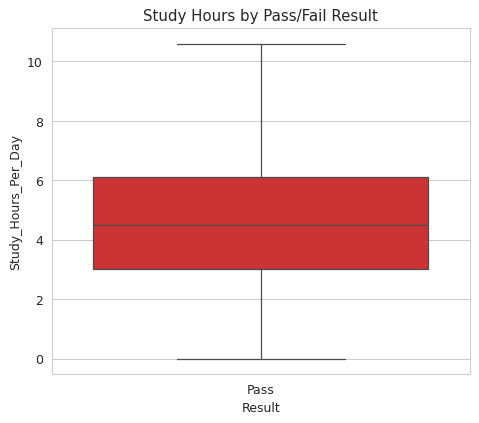

In [40]:
plt.figure(figsize=(6,5))
sns.boxplot(x='Result', y='Study_Hours_Per_Day', data=df_clean, palette='Set1')
plt.title('Study Hours by Pass/Fail Result')
plt.show()

### 5.34 Missing Data Pattern Before Cleaning (Heatmap)

Visualizes where missing values originally occurred in the raw dataset before imputation — a standard data-quality diagnostic.

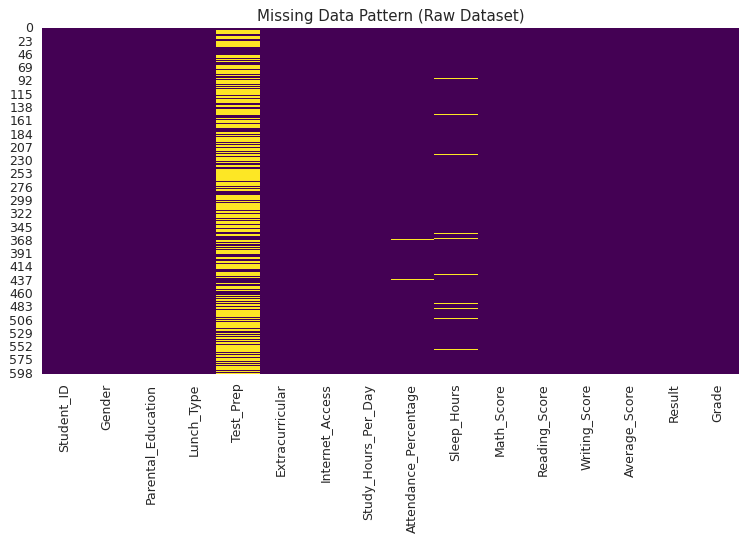

In [41]:
plt.figure(figsize=(10,5))
sns.heatmap(df.isna(), cbar=False, cmap='viridis')
plt.title('Missing Data Pattern (Raw Dataset)')
plt.show()

### 5.35 Study Hours vs Average Score Density (KDE Plot)

A 2D density plot showing where students concentrate in the study-hours vs average-score space, smoothing out the scatter plot into density contours.

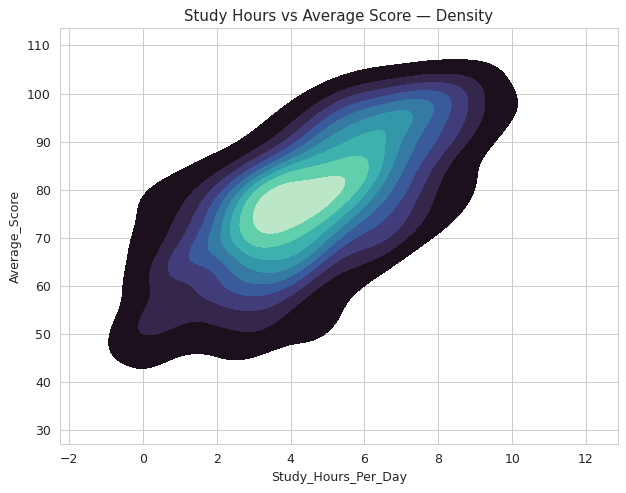

In [42]:
plt.figure(figsize=(8,6))
sns.kdeplot(x=df_clean['Study_Hours_Per_Day'], y=df_clean['Average_Score'], fill=True, cmap='mako')
plt.title('Study Hours vs Average Score — Density')
plt.show()

## 6. Summary of Key Insights

- **Study hours matter**: Students with more daily study hours tend to score higher on average, though the relationship has diminishing returns at the high end.
- **Attendance correlates with performance**: Higher attendance percentage is broadly associated with higher average scores.
- **Test preparation helps**: Students who completed a test-prep course scored noticeably higher on average than those who did not.
- **Socioeconomic factors show up**: Parental education level and lunch type both show visible differences in average score, consistent with commonly observed patterns in education datasets.
- **Sleep shows a mild effect**: Extremely low or high sleep hours are less common among top scorers, suggesting a moderate sleep range is associated with better performance.
- **Subjects are correlated**: Math, Reading, and Writing scores are positively correlated, meaning students strong in one subject tend to be strong in the others.
